In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    get_path,
    get_project_path,
    load_pickle_file,
    load_csv_file,
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from flonacomldft.utils.data_processing import load_datasets

from flonacomldft.utils.diagnostics import (
    R_hat,
    Target_Log_Prob,
)

from numpy.lib.stride_tricks import sliding_window_view

#from flonacomldft.free_energy_computations import (
#    compute_TFP_logratio, compute_deepBAR_logratio,
#    compute_TFP, compute_BAR
#)

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [4]:
EMT_DATA_PATH = get_path()+'/emt_andersen/'

## 1. EMT calculations

### 1.a MD configuration on FES and MLP dataset on FES

In [5]:
# load md data, train and test
xs_flow_emt = {key: load_csv_file('is1_flow_{:s}.csv'.format(key), EMT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']}

xs_mlp_emt = {key: load_csv_file('is1_mlp_{:s}.csv'.format(key), EMT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']}

In [6]:
# collective variables
cvs_flow_emt = {key: xs_flow_emt[key][:, -2:] for key in xs_flow_emt.keys()}
cvs_mlp_emt = {key: xs_mlp_emt[key][:, -2:] for key in xs_mlp_emt.keys()}

In [7]:
xs_flow_emt = load_datasets(md='emt_andersen', isomer_id=1, name='flow', real_centered=True, temperature=350)
xs_mlp_emt = load_datasets(md='emt_andersen', isomer_id=1, name='mlp', real_centered=True, temperature=350)

No figure provided. Cannot add colorbar.


Text(0.5, 0.98, 'Collective variables on energy surface (EMT)')

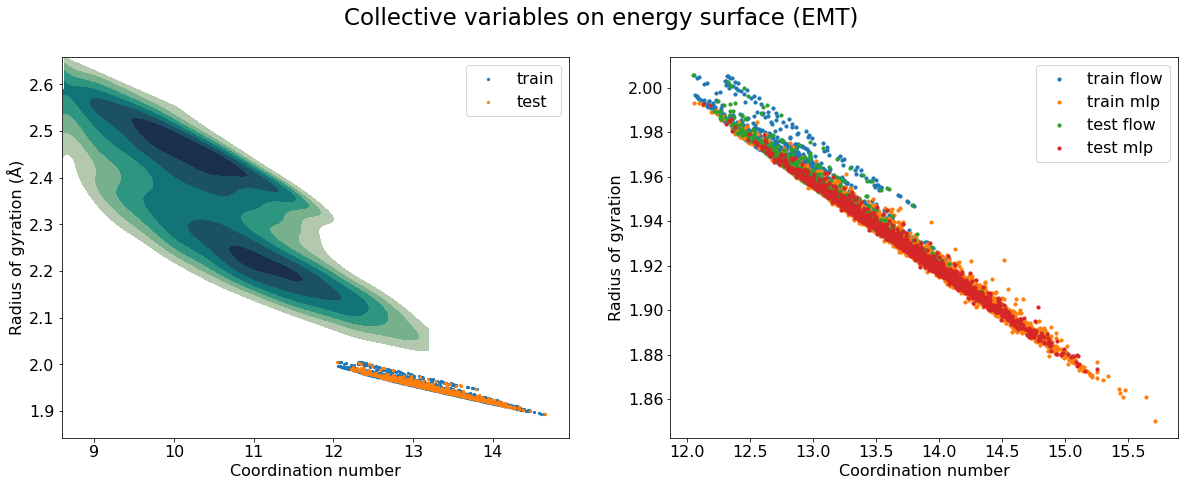

In [8]:
# plot fes

fig, axs = plt.subplots(1, 2, figsize=(20,7))

plot_energy_surface(ax=axs[0])

for key in cvs_flow_emt.keys():

    axs[0].scatter(cvs_flow_emt[key][:, 0], cvs_flow_emt[key][:, 1], s=5, label=key)

    for cvs, label in zip([cvs_flow_emt, cvs_mlp_emt], ['flow', 'mlp']):
        axs[1].scatter(cvs[key][:, 0], cvs[key][:, 1], s=10, label=key +' '+ label)

    axs[1].set_xlabel('Coordination number')
    axs[1].set_ylabel('Radius of gyration')

axs[0].legend()
axs[1].legend()

fig.suptitle('Collective variables on energy surface (EMT)', fontsize=23)

### 1.b MLP model for EMT

In [9]:
dict_mlp_model_emt = load_pickle_file('dict_mlp_model_is1.pkl', EMT_DATA_PATH + 'models')

In [10]:
emt_model = dict_mlp_model_emt['model']
losses = { key: torch.tensor(dict_mlp_model_emt[key+'_loss']) for key in ['train', 'test']}

us_flow_pred = {key: emt_model(xs_flow_emt[key][:, :12]).detach()
                for key in xs_flow_emt.keys()}

us_mlp_pred = {key: emt_model(xs_mlp_emt[key][:, :12]).detach()
                for key in xs_mlp_emt.keys()}

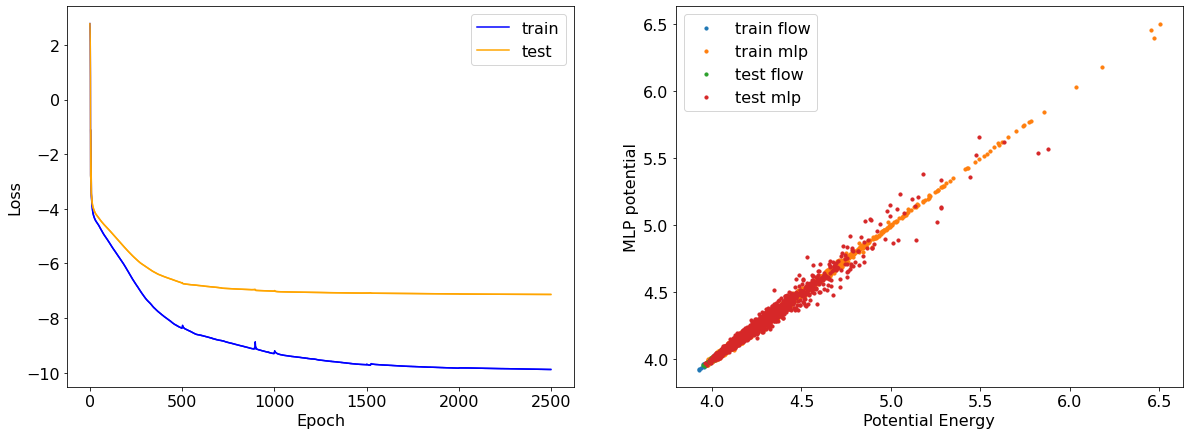

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20,7))

colors = ['Blue', 'Orange']

for i, key in enumerate(us_flow_pred.keys()):
    set_plot_sequential_data(losses[key].log(), label=key, ax=axs[0], alpha=1, color=colors[i])

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')

axs[0].legend()


for key in us_flow_pred.keys():
    for xs, us, label in zip([xs_flow_emt, xs_mlp_emt], [us_flow_pred, us_mlp_pred], ['flow', 'mlp']):
        axs[1].scatter(xs[key][:, 12].detach(), us[key].flatten().detach(), s=10, label=key +' '+ label)

axs[1].set_xlabel('Potential Energy')
axs[1].set_ylabel('MLP potential')

axs[1].legend()

### 1.c Adaptive EMT with and without MLP

In [3]:
EMT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-emt/'
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

In [13]:
adaptive_emt_path = ['1-adaptive/results_adaptive_is1_28665681/adaptive_sampling_is1_28665681.pkl']
adaptive_emt_mlp_path = ['2-adaptive-mlp/results_adaptive_is1_28690164/adaptive_sampling_is1_28690164.pkl']

In [14]:
adaptives_mcmc_emt = [load_pickle_file(adaptive_file, EMT_SIMS_PATH) for adaptive_file in adaptive_emt_path]
adaptives_mcmc_emt_mlp = [load_pickle_file(adaptive_file, EMT_SIMS_PATH) for adaptive_file in adaptive_emt_mlp_path]

### 1.c.i MLP loss

In [15]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_emt_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_emt_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(1)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_emt_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_emt_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(1)]

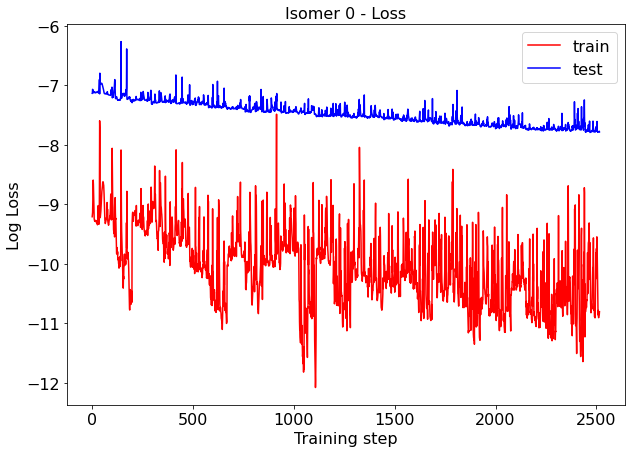

In [16]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 1.c.ii Flow loss

In [17]:
losses_emt = [torch.cat([adaptives_mcmc_emt[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_emt[i]['dict_flows_training']))
                            ]) 
                            for i in range(1)]
                          
losses_emt_mlp = [torch.cat([adaptives_mcmc_emt_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_emt_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(1)]

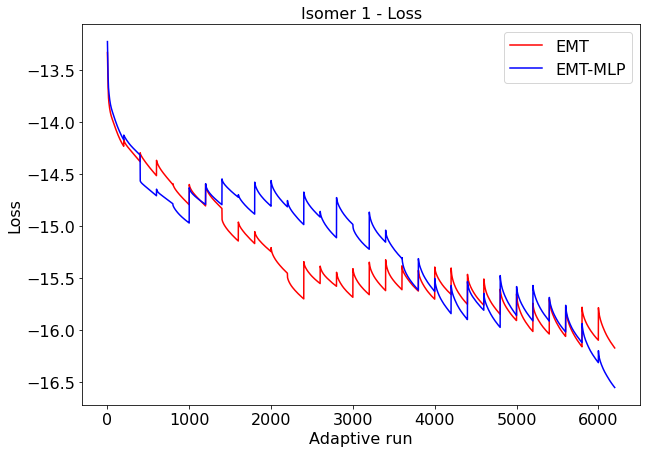

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

#grad_steps = [200, 100]

for i in range(len(losses_emt)):
    set_plot_sequential_data(losses_emt[i], ax=axs[i], color='red', label='EMT', alpha=1, avg=False)
    set_plot_sequential_data(losses_emt_mlp[i], ax=axs[i], color='blue', label='EMT-MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer 1 - Loss')

    axs[i].legend()

### 1.c.iii Acceptance ratio

In [19]:
accs_emt = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_emt]
accs_emt_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

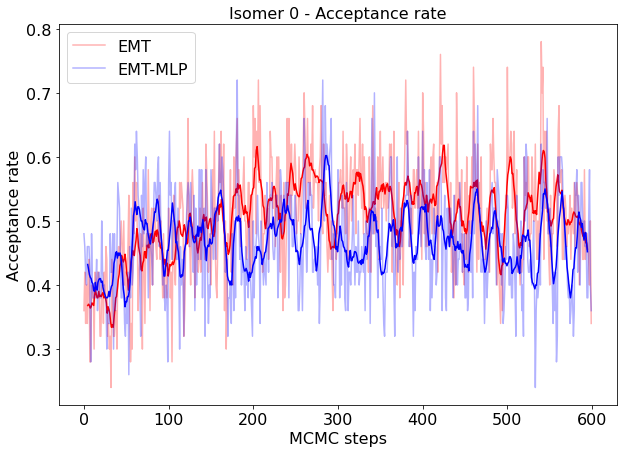

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(len(accs_emt_mlp)):

    set_plot_sequential_data(accs_emt[i], ax=axs[i], color='red', label='EMT')
    set_plot_sequential_data(accs_emt_mlp[i], ax=axs[i], color='blue', label='EMT-MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

### 1.c.iv $\hat{R}$ test (Real centered coordinates)

In [21]:
xs_emt = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_emt]
xs_emt_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [22]:
rhat_emt = [R_hat(x) for x in xs_emt]
rhat_emt_mlp = [R_hat(x) for x in xs_emt_mlp]

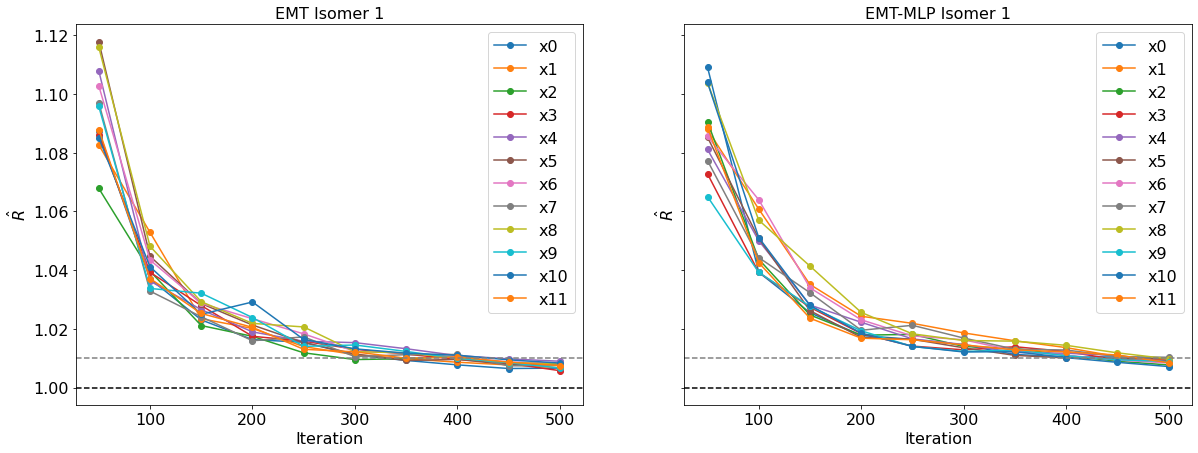

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

axs= [axs]

for i in range(len(rhat_emt)):
    axs[i][0].plot(rhat_emt[i][1], rhat_emt[i][0], '-o',  label=rhat_emt[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('EMT Isomer 1')

    axs[i][1].plot(rhat_emt_mlp[i][1], rhat_emt_mlp[i][0], '-o',  label=rhat_emt_mlp[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('EMT-MLP Isomer 1')

### 1.c.v Collective variables

In [24]:
coord_mapping = Coordinates_mapping(etype='emt')

In [25]:
xs_emt = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_emt]
xs_emt_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [26]:
C_emt = []
R_emt = []

for i in range(len(xs_emt)):
    
    C = []
    R = []

    for j in range(xs_emt[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_emt[i][j], isomer=1)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_emt.append(torch.stack(C))
    R_emt.append(torch.stack(R))

In [27]:
C_emt_mlp = []
R_emt_mlp = []

for i in range(len(xs_emt_mlp)):
    
    C = []
    R = []

    for j in range(xs_emt_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_emt_mlp[i][j], isomer=1)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_emt_mlp.append(torch.stack(C))
    R_emt_mlp.append(torch.stack(R))

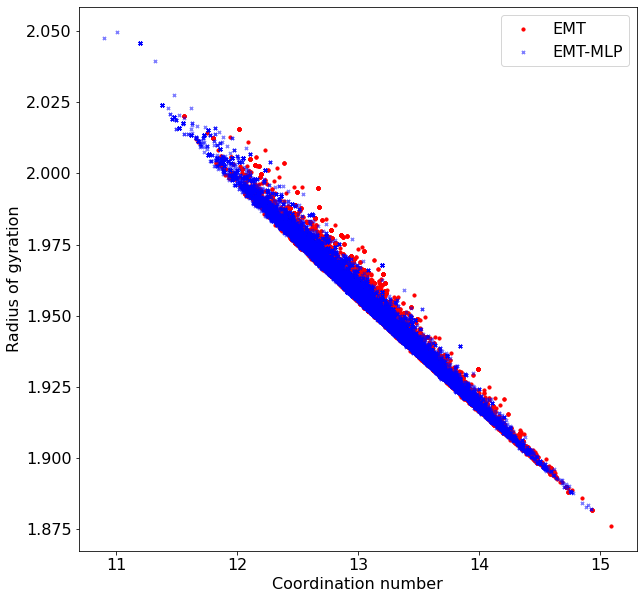

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.scatter(C_emt[0].flatten().detach().numpy(), R_emt[0].flatten().detach().numpy(), s=10, c='red', label='EMT')
ax.scatter(C_emt_mlp[0].flatten().detach().numpy(), R_emt_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='EMT-MLP', marker='x', alpha=0.5)

#ax.scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
#ax.scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)

ax.set_xlabel('Coordination number')
ax.set_ylabel('Radius of gyration')

ax.legend()

### 1.c.vi Energy histograms

In [29]:
us_emt = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_emt]
us_emt_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_emt_mlp]

In [30]:
dfs = [{'EMT': us_emt[i].flatten().detach(), 
        'EMT-MLP': us_emt_mlp[i].flatten().detach()} for i in range(1)]

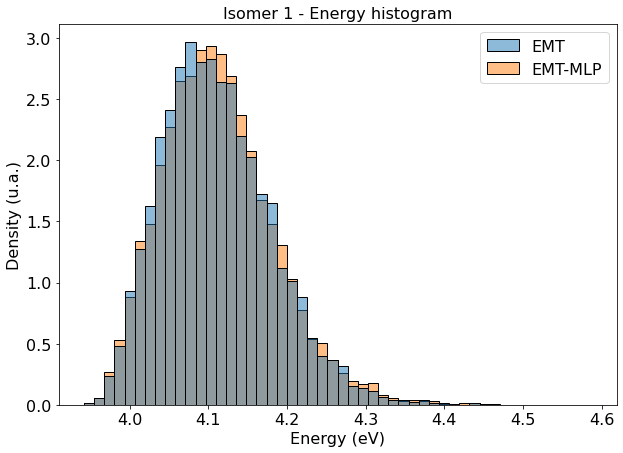

In [31]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

axs = [axs]

for i in range(1):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer 1 - Energy histogram')

## 2. DFT calculations

In [4]:
DFT_DATA_PATH = get_path() + '/andersen/'

### 2.a MD configuration on FES and MLP dataset on FES

In [33]:
# load md data, train and test
xs_flow_dft = [{key: load_csv_file('is{:d}_flow_{:s}.csv'.format(i, key), DFT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']} for i in range(2)]

xs_mlp_dft = [{key: load_csv_file('is{:d}_mlp_{:s}.csv'.format(i, key), DFT_DATA_PATH + 'datasets') 
            for key in ['train', 'test']} for i in range(2)]

In [34]:
# collective variables
cvs_flow_dft = [{key: xs[key][:, -2:] for key in xs.keys()} for xs in xs_flow_dft]
cvs_mlp_dft = [{key: xs[key][:, -2:] for key in xs.keys()} for xs in xs_mlp_dft]

In [8]:
xs_flow_dft = [load_datasets(md='andersen', isomer_id=i, name='flow', real_centered=True, temperature=350)
                for i in range(2)]
xs_mlp_dft = [load_datasets(md='andersen', isomer_id=i, name='mlp', real_centered=True, temperature=350)
                for i in range(2)]

In [37]:
cvs_flow_dft[0].keys()

dict_keys(['train', 'test'])

Text(0.5, 0.98, 'Collective variables on energy surface (EMT)')

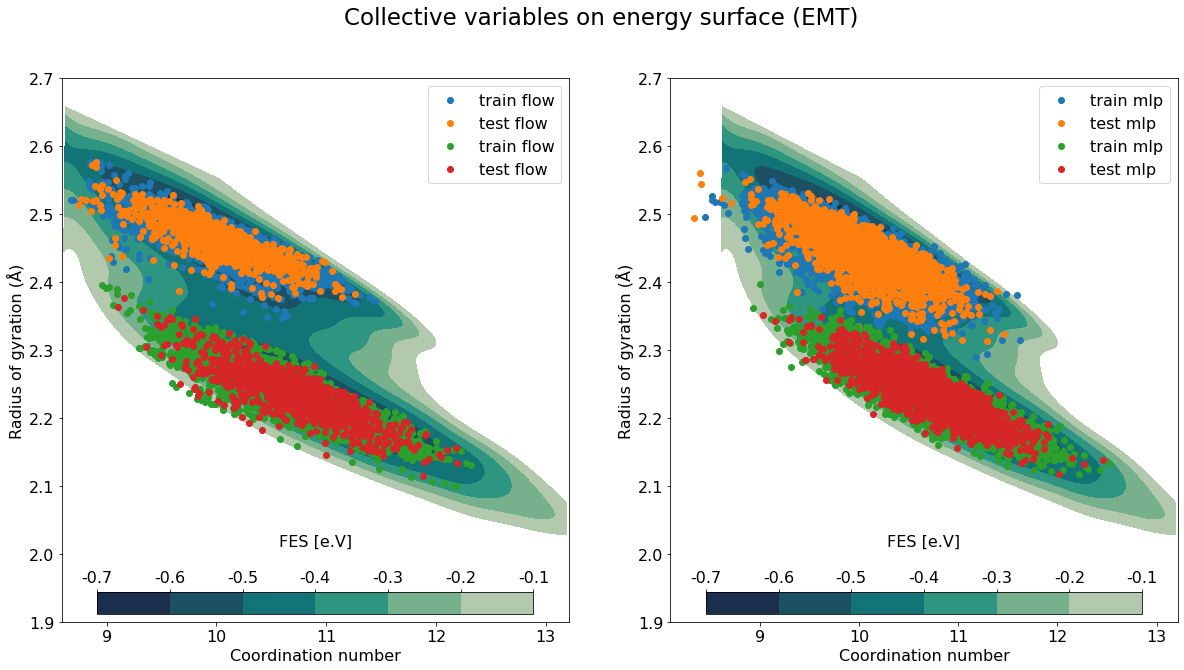

In [46]:
# plot fes

fig, axs = plt.subplots(1, 2, figsize=(20,10))

plot_energy_surface(fig=fig, ax=axs[0])
plot_energy_surface(fig=fig, ax=axs[1])

for cvs, ax, label in zip([cvs_flow_dft, cvs_mlp_dft], axs, ['flow', 'mlp']):
    for cv in cvs:
        ax.scatter(cv['train'][:, 0], cv['train'][:, 1], label='train'+' '+label)   
        ax.scatter(cv['test'][:, 0], cv['test'][:, 1], label='test'+' '+label)   

#for key in cvs_flow_emt.keys():
#
#    axs[0].scatter(cvs_flow_emt[key][:, 0], cvs_flow_emt[key][:, 1], s=5, label=key)
#
#    for cvs, label in zip([cvs_flow_emt, cvs_mlp_emt], ['flow', 'mlp']):
#        axs[1].scatter(cvs[key][:, 0], cvs[key][:, 1], s=10, label=key +' '+ label)
#
#    axs[1].set_xlabel('Coordination number')
#    axs[1].set_ylabel('Radius of gyration')

        ax.legend()

fig.suptitle('Collective variables on energy surface (EMT)', fontsize=23)

### 2.b MLP model for DFT

In [5]:
dict_mlp_models_dft = [load_pickle_file('dict_mlp_model_is{:d}.pkl'.format(i), DFT_DATA_PATH + 'models')
                        for i in range(2)]

In [9]:
dft_models = [dict_mlp['model'] for dict_mlp in dict_mlp_models_dft]

losses = [{ key: torch.tensor(dict_mlp[key+'_loss']) for key in ['train', 'test']}
                for dict_mlp in dict_mlp_models_dft]

us_flow_pred_dft = [ {key: dft_model(xs[key][:, :12]).detach()
                for key in xs.keys()} for dft_model, xs in zip(dft_models, xs_flow_dft)]

us_mlp_pred_dft = [{key: dft_model(xs[key][:, :12]).detach()
                for key in xs.keys()} for dft_model, xs in zip(dft_models, xs_mlp_dft)]

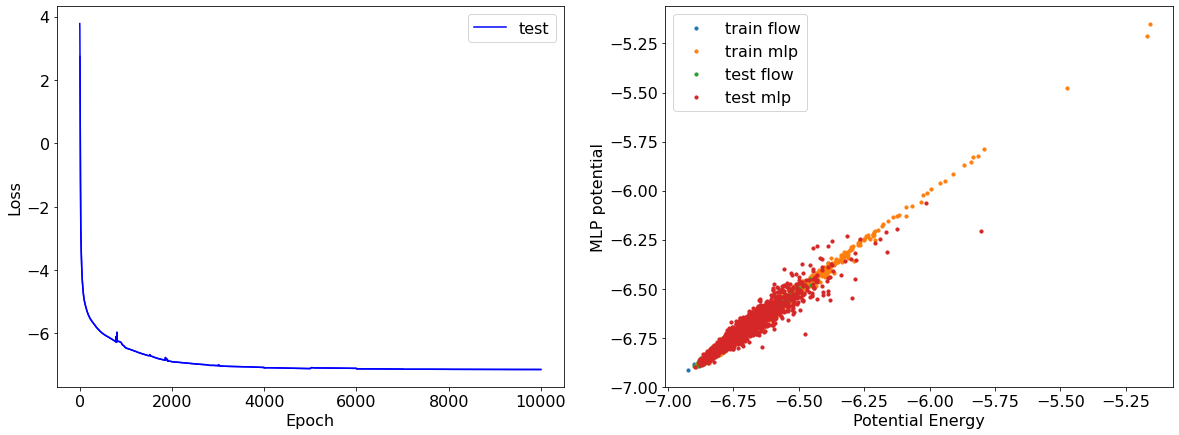

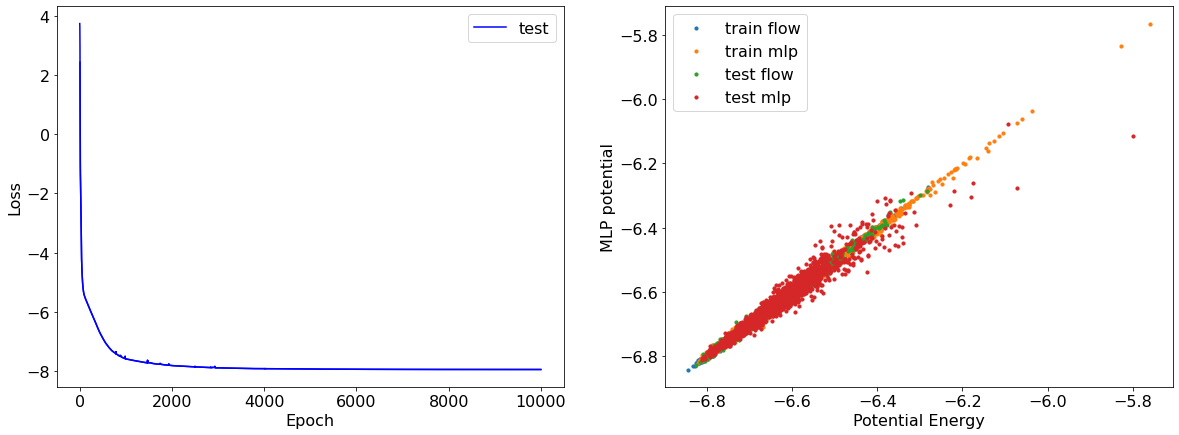

In [12]:
for j in range(2):

    fig, axs = plt.subplots(1, 2, figsize=(20,7))

    colors = ['Blue', 'Orange']


    for i, key in enumerate(['test']):#us_flow_pred_dft[j].keys()):
        set_plot_sequential_data(losses[j][key].log(), label=key, ax=axs[0], alpha=1, color=colors[i])

    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')

    axs[0].legend()
    #axs[0].set_xlim(8000, 10000)


    for key in us_flow_pred_dft[j].keys():
        for xs, us, label in zip([xs_flow_dft[j], xs_mlp_dft[j]], [us_flow_pred_dft[j], us_mlp_pred_dft[j]], ['flow', 'mlp']):
            axs[1].scatter(xs[key][:, 12].detach(), us[key].flatten().detach(), s=10, label=key +' '+ label)

    axs[1].set_xlabel('Potential Energy')
    axs[1].set_ylabel('MLP potential')

    axs[1].legend()
    #axs[1].set_xlim(8000, 10000)

### 2.c Adaptive DFT with and without MLP

In [50]:
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

In [51]:
adaptives_mcmc_dft = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_dft_path]
adaptives_mcmc_mlp = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_mlp_path]

### 2.d MLP losses for DFT

In [52]:
losses_mlp_train = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['train_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptives_mcmc_mlp[i]['dict_mlps_training'][j][0]['test_loss'])
                            for j in range(1, len(adaptives_mcmc_mlp[i]['dict_mlps_training']))
                            ])
                            for i in range(2)]

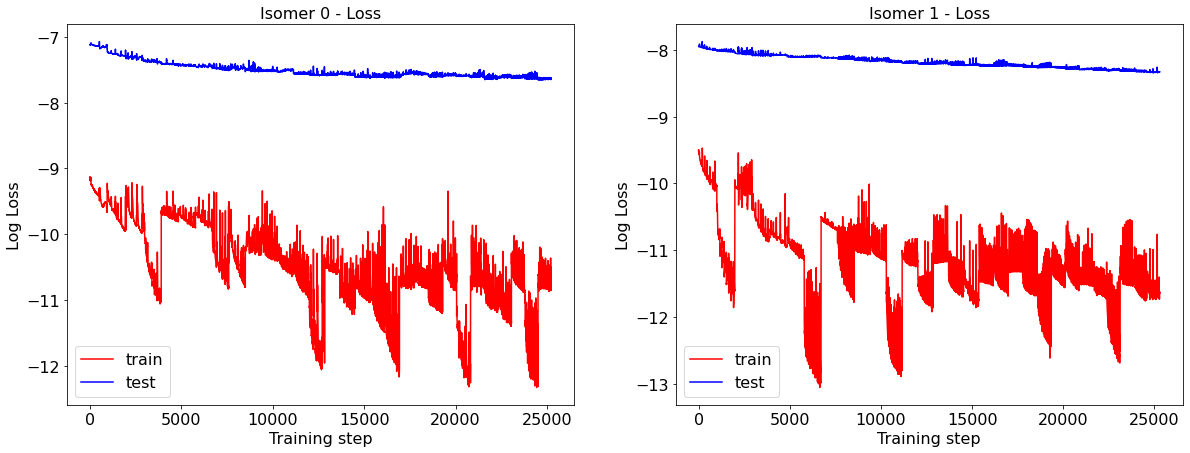

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 2.e Flow losses DFT

In [57]:
losses_dft = [torch.cat([adaptives_mcmc_dft[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_dft[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                          
losses_mlp = [torch.cat([adaptives_mcmc_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(2)]

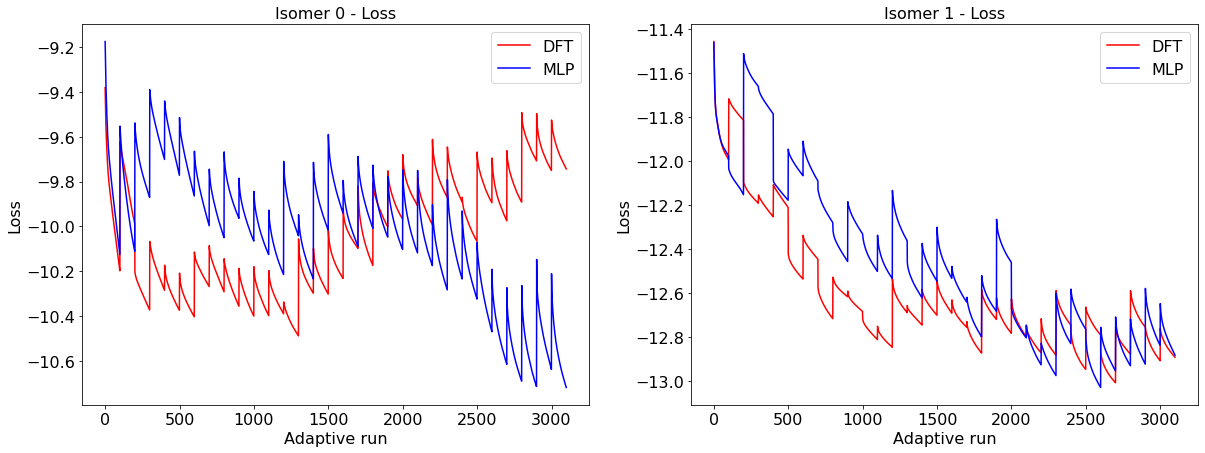

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [2, 1]

for i in range(len(losses_dft)):
    set_plot_sequential_data(losses_dft[i], ax=axs[i], color='red', label='DFT', alpha=1, avg=False)
    set_plot_sequential_data(losses_mlp[i][::grad_steps[i]], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 3.f Acceptance ratio with DFT and MLP-DFT

In [59]:
accs_dft = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_dft]
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

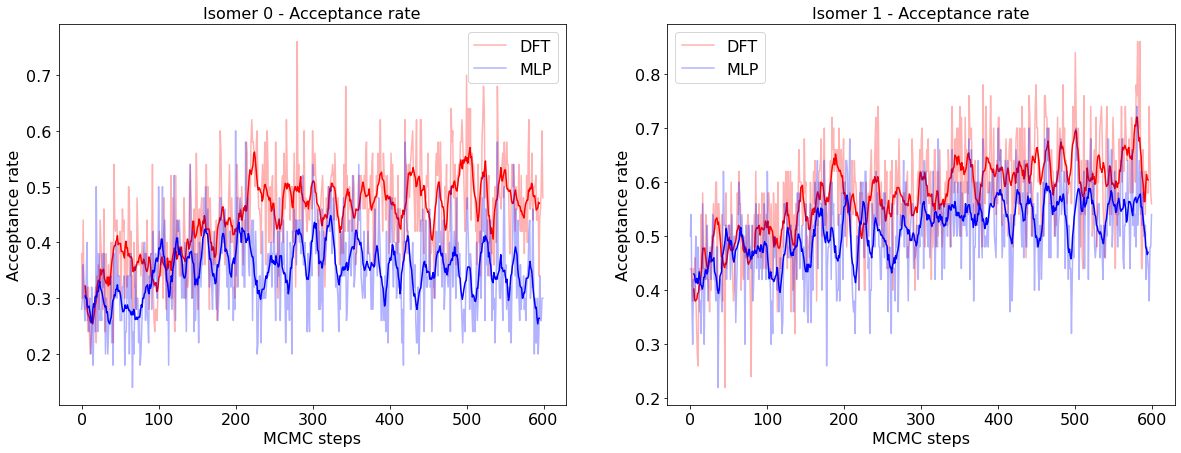

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(accs_dft)):

    set_plot_sequential_data(accs_dft[i], ax=axs[i], color='red', label='DFT')
    set_plot_sequential_data(accs_mlp[i], ax=axs[i], color='blue', label='MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

### 2.g $\hat{R}$ test

In [62]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_mlp]

In [63]:
rhat_dft = [R_hat(x) for x in xs_dft]
rhat_mlp = [R_hat(x) for x in xs_mlp]

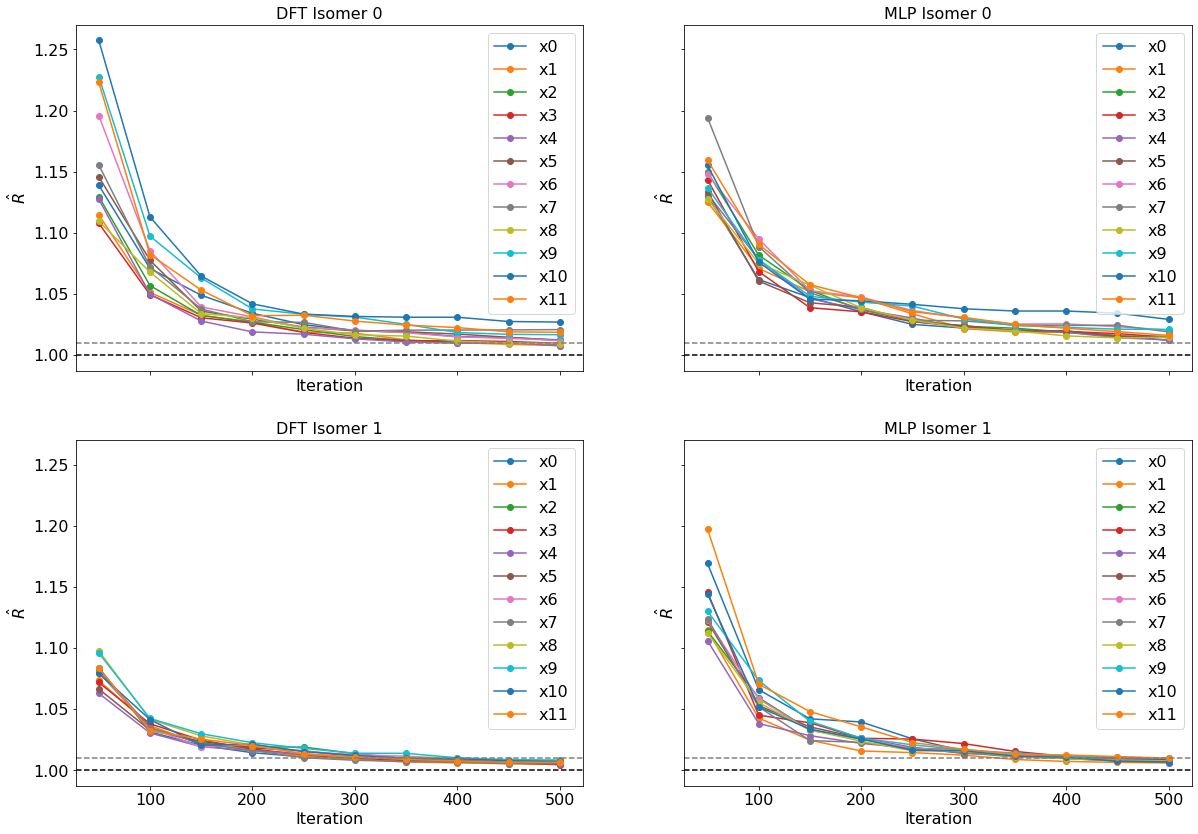

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=True, sharey=True)

for i in range(len(rhat_dft)):
    axs[i][0].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    axs[i][0].axhline(1, c='k', ls='--')
    axs[i][0].axhline(1.01, c='grey', ls='--')
    axs[i][0].set_xlabel('Iteration')
    axs[i][0].set_ylabel(r'$\hat{R}$')
    axs[i][0].legend()
    axs[i][0].set_title('DFT Isomer {}'.format(i))

    axs[i][1].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label=rhat_mlp[i][2])
    axs[i][1].axhline(1, c='k', ls='--')
    axs[i][1].axhline(1.01, c='grey', ls='--')
    axs[i][1].set_xlabel('Iteration')
    axs[i][1].set_ylabel(r'$\hat{R}$')
    axs[i][1].legend()
    axs[i][1].set_title('MLP Isomer {}'.format(i))

### 2.h Collective variables

In [68]:
coord_mapping = Coordinates_mapping(etype='dft')

In [69]:
xs_dft = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_dft]
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach() for adaptive_mcmc in adaptives_mcmc_mlp]

In [70]:
C_dft = []
R_dft = []

for i in range(len(xs_dft)):
    
    C = []
    R = []

    for j in range(xs_dft[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_dft[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_dft.append(torch.stack(C))
    R_dft.append(torch.stack(R))

In [71]:
C_mlp = []
R_mlp = []

for i in range(len(xs_mlp)):
    
    C = []
    R = []

    for j in range(xs_mlp[i].shape[0]):

        cvs = coord_mapping.get_collective_variables_from_real_centered(xs_mlp[i][j], isomer=i)
        C.append(cvs[:, 0].flatten())
        R.append(cvs[:, 1].flatten())

    C_mlp.append(torch.stack(C))
    R_mlp.append(torch.stack(R))

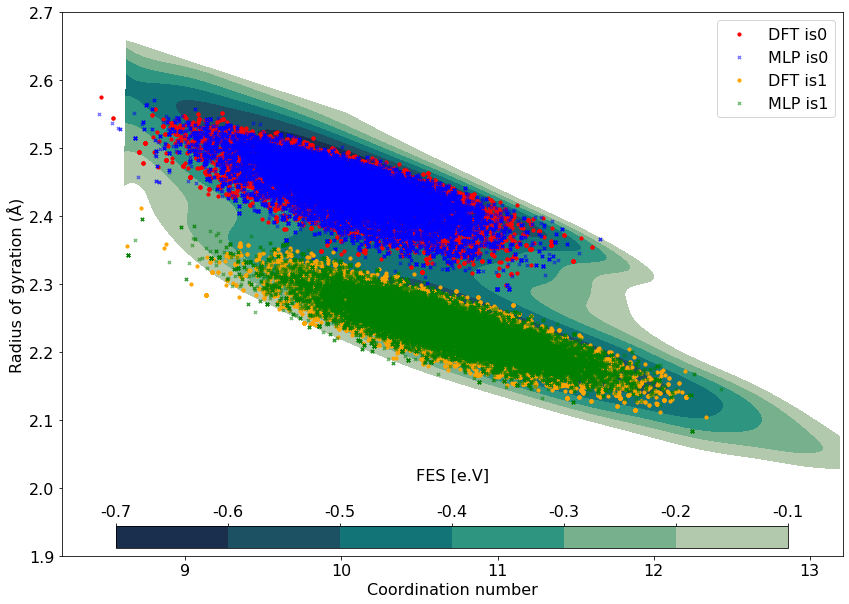

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

plot_energy_surface(ax=ax, fig=fig)

ax.scatter(C_dft[0].flatten().detach().numpy(), R_dft[0].flatten().detach().numpy(), s=10, c='red', label='DFT is0')
ax.scatter(C_mlp[0].flatten().detach().numpy(), R_mlp[0].flatten().detach().numpy(), s=10, c='blue', label='MLP is0', marker='x', alpha=0.5)

ax.scatter(C_dft[1].flatten().detach().numpy(), R_dft[1].flatten().detach().numpy(), s=10, c='orange', label='DFT is1')
ax.scatter(C_mlp[1].flatten().detach().numpy(), R_mlp[1].flatten().detach().numpy(), s=10, c='green', label='MLP is1', marker='x', alpha=0.5)

ax.legend()

### 2.i Energy histograms

In [109]:
us_dft = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_dft]
us_mlp = [torch.cat(adaptive_mcmc['us']) for adaptive_mcmc in adaptives_mcmc_mlp]

In [110]:
dfs = [{'DFT': us_dft[i].flatten().detach(), 
        'MLP': us_mlp[i].flatten().detach()} for i in range(2)]

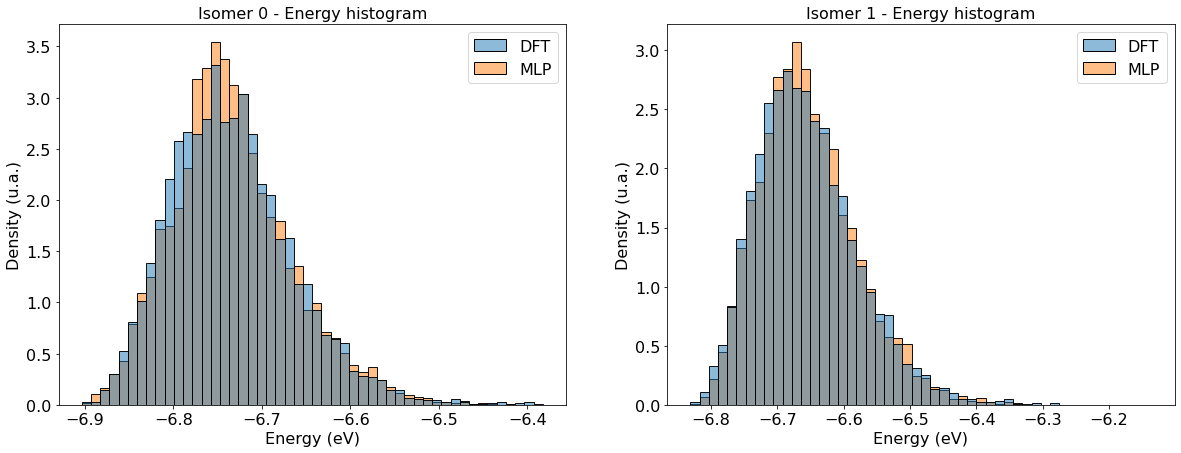

In [111]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(2):
    plot_energy_histogram(dfs[i], ax=axs[i], bins=50, alpha=0.5)
    axs[i].set_title(f'Isomer {i} - Energy histogram')

## 3. Adaptive multimodal sampling

In [20]:
adaptive_multimodal_dft_path = ['3-adaptive-multimodal/results_adaptive_mixture_28918870/adaptive_sampling_mixture_28918870.pkl',
                                '4-adaptive-multimodal-mlp/results_adaptive_mixture_28978453/adaptive_sampling_mixture_28978453.pkl']

In [21]:
adaptive_multimodal = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_multimodal_dft_path]

### 3.a MLP losses

In [17]:
i=1
losses_mlp_train = [torch.cat([torch.tensor(adaptive_multimodal[i]['dict_mlps_training'][j][k]['train_loss'])
                            for j in range(1, len(adaptive_multimodal[i]['dict_mlps_training']))
                            ]) 
                            for k in range(2)]

losses_mlp_test = [torch.cat([torch.tensor(adaptive_multimodal[i]['dict_mlps_training'][j][k]['test_loss'])
                            for j in range(1, len(adaptive_multimodal[i]['dict_mlps_training']))
                            ])
                            for k in range(2)]

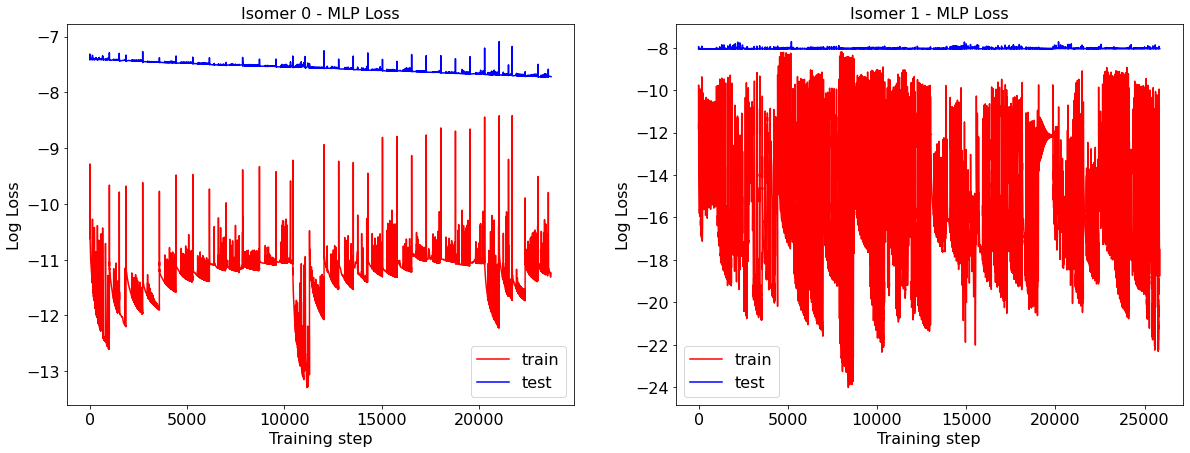

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp_train)):
    set_plot_sequential_data(torch.log(losses_mlp_train[i]), ax=axs[i], color='red', label='train', alpha=1, avg=False)
    set_plot_sequential_data(torch.log(losses_mlp_test[i]), ax=axs[i], color='blue', label='test', alpha=1, avg=False)

    axs[i].set_xlabel('Training step')
    axs[i].set_ylabel('Log Loss')
    axs[i].set_title(f'Isomer {i} - MLP Loss')

    axs[i].legend()

### 3.b Flow losses

In [19]:
losses_flow = [[torch.cat([adaptive_multimodal[i]['dict_flows_training'][j][k]['losses'][0]
                            for j in range(len(adaptive_multimodal[i]['dict_flows_training']))
                            ]) 
                            for i in range(2)]
                            for k in range(2)]


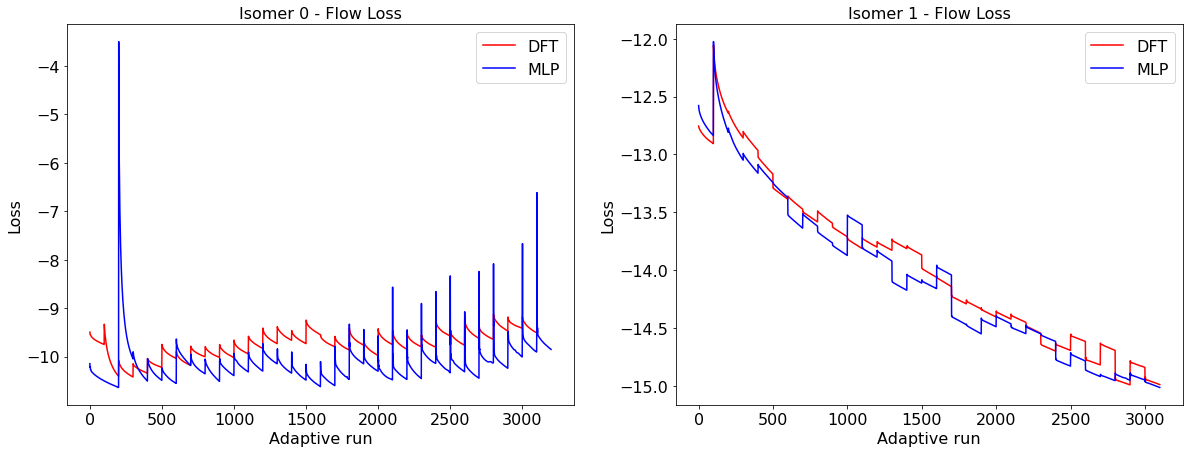

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

grad_steps = [2, 1]

for i in range(len(losses_flow)):
    set_plot_sequential_data(losses_flow[i][0], ax=axs[i], color='red', label='DFT', alpha=1, avg=False)
    set_plot_sequential_data(losses_flow[i][1], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    #set_plot_sequential_data(losses_flow[i][0][200:][::2], ax=axs[i], color='red', alpha=1, avg=False, init=200)
                             
    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Flow Loss')

    axs[i].legend()

### 3.c Acceptance ratio

In [21]:
accs = [torch.cat(adaptive['accs']).mean(dim=1) for adaptive in adaptive_multimodal]

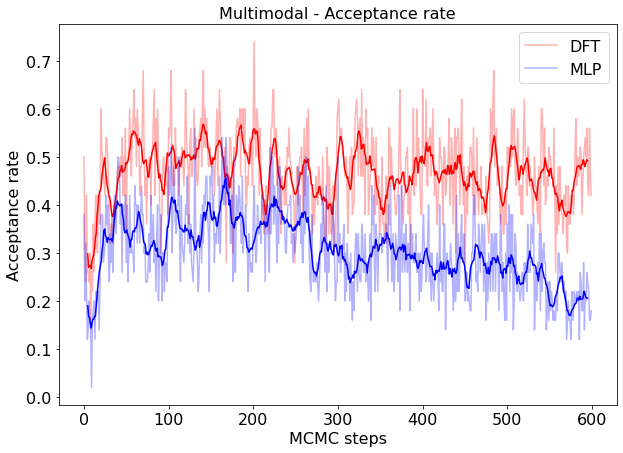

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

set_plot_sequential_data(accs[0], ax=axs, color='red', label='DFT')
set_plot_sequential_data(accs[1], ax=axs, color='blue', label='MLP')
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Acceptance rate')
axs.set_title(f'Multimodal - Acceptance rate')
axs.legend()

### 3.e Colective variables

In [55]:
def cvs_from_adaptive(adaptive):

    coord_mapping = Coordinates_mapping(etype='dft')

    xs = torch.cat(adaptive['xs']).detach()

    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = torch.cat(adaptive['isomers']).reshape(-1, 1)

    xs_is0 = []
    xs_is1 = []

    for isomer, x in zip(isomers_mask, xs_flatten):

        if (isomer[0]==0).item():
            xs_is0.append(x)
        else:
            xs_is1.append(x)

    xs_is0 = torch.stack(xs_is0) 
    xs_is1 = torch.stack(xs_is1) 

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)
    cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

    return cvs_is0, cvs_is1

In [56]:
cvs = [cvs_from_adaptive(adaptive) for adaptive in adaptive_multimodal]

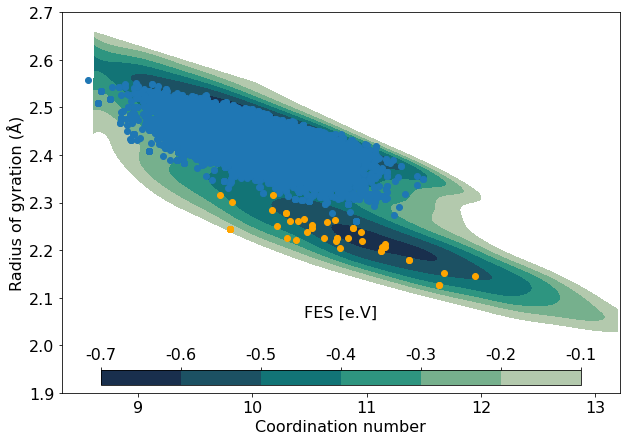

In [57]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))

plot_energy_surface(fig=fig, ax=ax)

ax.scatter(cvs[0][0][:, 0], cvs[0][0][:, 1], )
ax.scatter(cvs[0][1][:, 0], cvs[0][1][:, 1], c='orange')

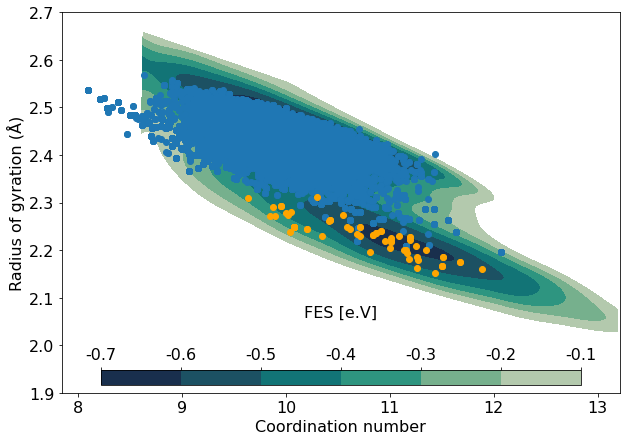

In [58]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))

plot_energy_surface(fig=fig, ax=ax)

ax.scatter(cvs[1][0][:, 0], cvs[1][0][:, 1], )
ax.scatter(cvs[1][1][:, 0], cvs[1][1][:, 1], c='orange')

### 3.d Rhat test

In [22]:
def get_zmat_for_rhat(xs, isomers):

    coord_mapping = Coordinates_mapping()

    zmat = torch.zeros(xs.shape)

    for i in range(xs.shape[1]):
        for j in range(xs.shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                        isomer=isomers[j, i])[0]
    zmat = zmat.clone().detach().numpy()

    return zmat

In [23]:
xs_rhat = [torch.cat(adaptive['xs']).detach().numpy().transpose(1, 0, 2) for adaptive in adaptive_multimodal]
isomers_rhat = [torch.cat(adaptive['isomers']).detach().numpy().transpose(1, 0) for adaptive in adaptive_multimodal]

In [24]:
zmats = [get_zmat_for_rhat(x, isomer) for x, isomer in zip(xs_rhat, isomers_rhat)]

In [25]:
rhat_dft = [R_hat(zmat) for zmat in zmats]

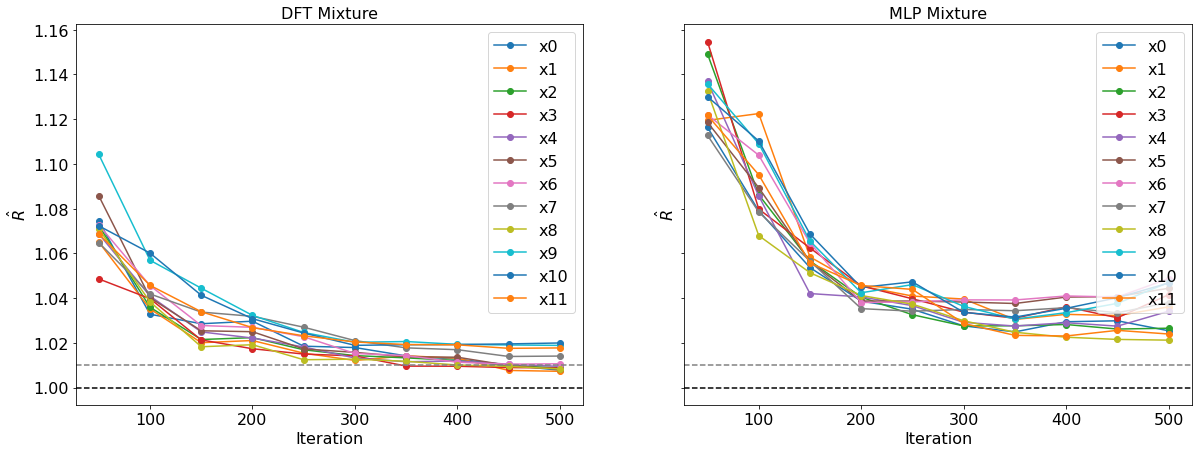

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=True)

labels = ['DFT', 'MLP']

for i in range(len(rhat_dft)):
    axs[i].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('{:s} Mixture'.format(labels[i]))

### 3.e Isomers

In [167]:
isomers = [torch.cat(adaptive_mcmc['isomers']).detach() for adaptive_mcmc in adaptive_multimodal]

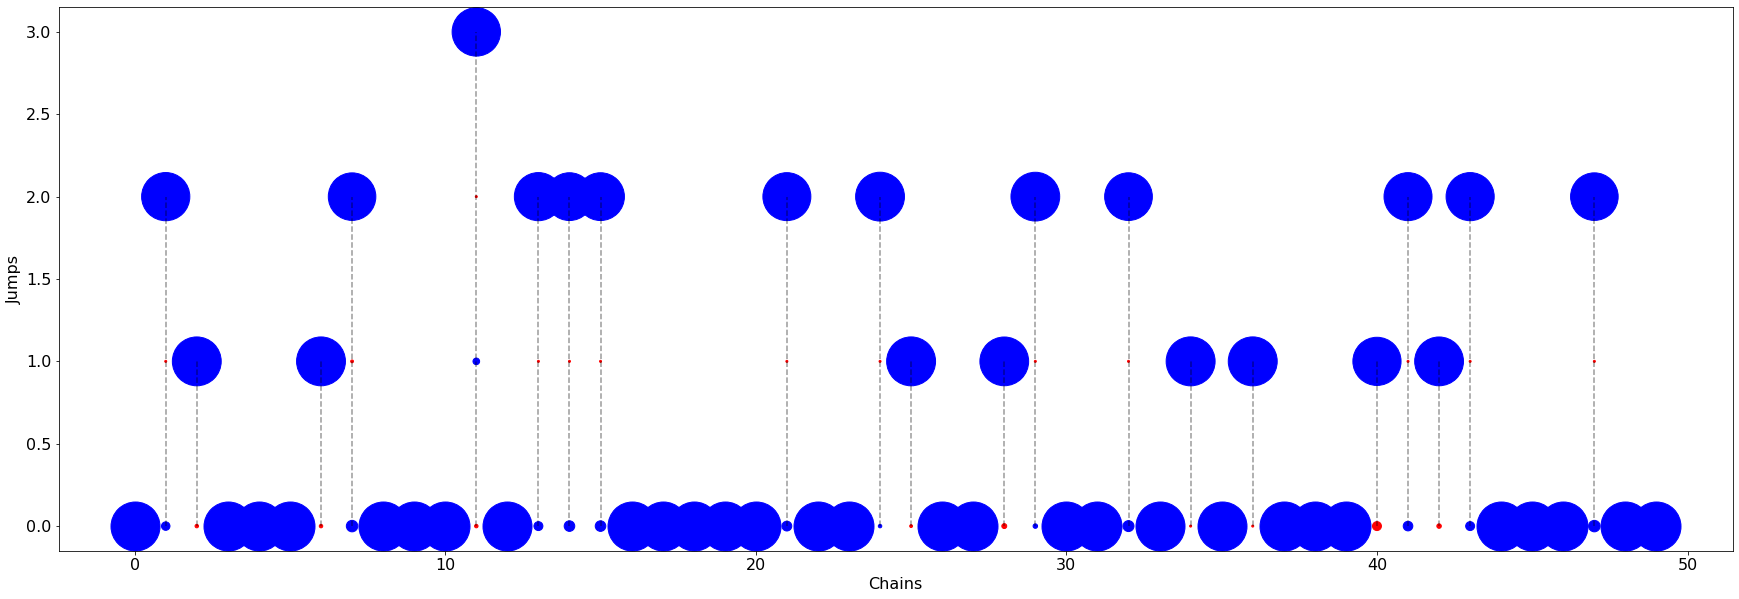

In [170]:
isomers_dft = isomers[0].T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(isomers_dft.shape[0]):

    jumps, counts = isomers_dft[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    #print(colors_array)
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*4, color=colors_array)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

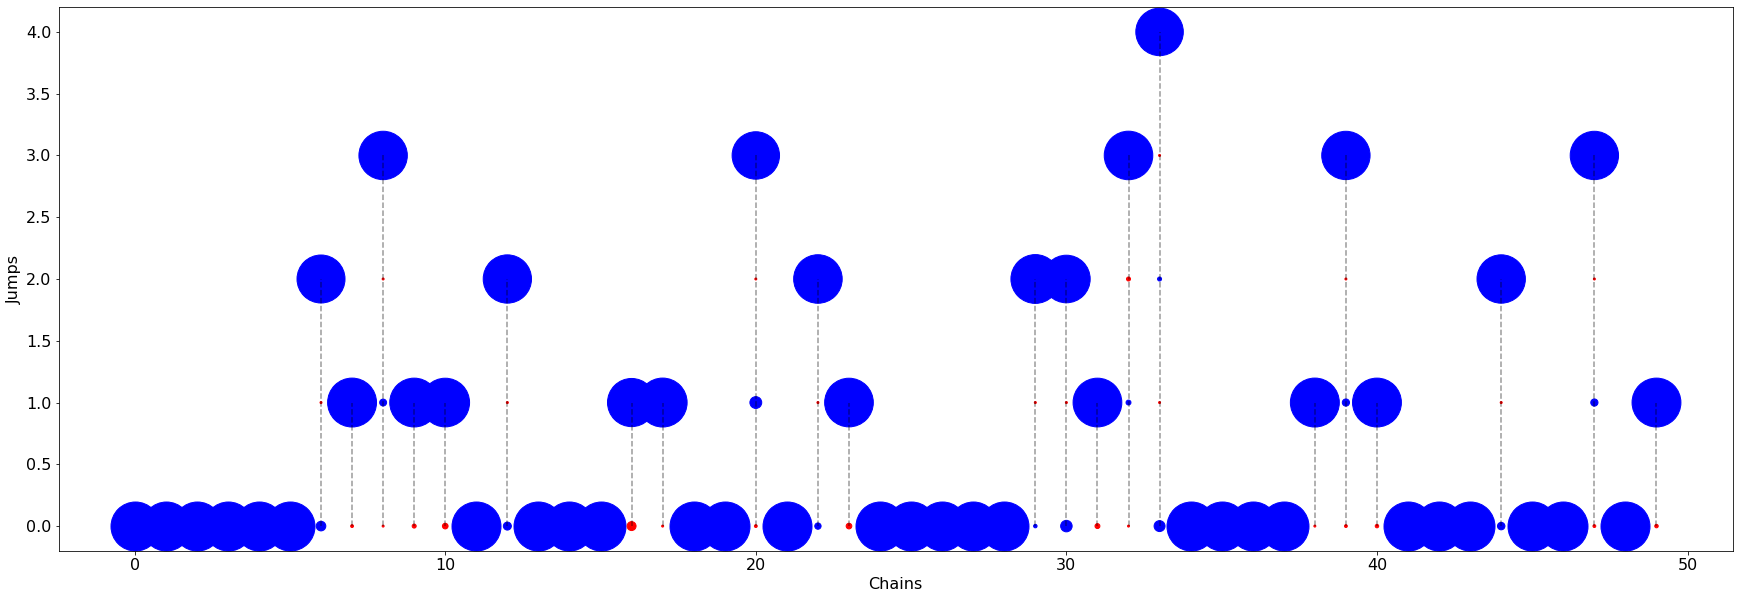

In [171]:
isomers_mlp = isomers[1].T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(isomers_mlp.shape[0]):

    jumps, counts = isomers_mlp[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    #print(colors_array)
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*4, color=colors_array)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

In [161]:
isomers = [torch.cat(adaptive_mcmc['isomers']).detach() for adaptive_mcmc in adaptive_multimodal]
accs = [torch.cat(adaptive_mcmc['accs']).detach() for adaptive_mcmc in adaptive_multimodal]

Text(0.5, 1.0, 'MLP')

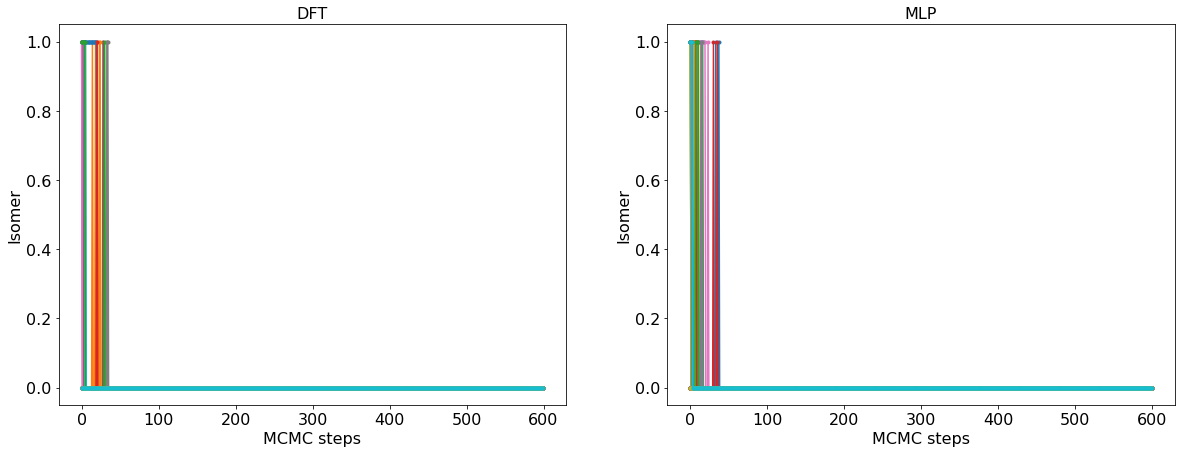

In [162]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
ax[0].plot(isomers[0], '.-')
ax[0].set_xlabel('MCMC steps')
ax[0].set_ylabel('Isomer')
ax[0].set_title('DFT')

ax[1].plot(isomers[1], '.-')
ax[1].set_xlabel('MCMC steps')
ax[1].set_ylabel('Isomer')
ax[1].set_title('MLP')

In [74]:
#accs = torch.cat(adaptive_multimodal[0]['accs']).T
#isomers = torch.cat(adaptive_multimodal[0]['isomers']).T
#
#fig, ax = plt.subplots(1, 1, figsize=(30, 10))
#
#for i in range(accs.shape[0]):
#
#    jumps, counts = accs[i].unique_consecutive(return_counts=True)
#    #print(jumps, counts)
#    colors_array = []
#    for j in range(jumps.shape[0]):
#        if jumps[j]==0:
#            colors_array.append('blue')
#        else:
#            colors_array.append('red')
#    marker = 'o' if isomers[i].unique()==0 else 'x'
#    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
#    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*5, color=colors_array, marker=marker)
#    ax.set_xlabel('Chains')
#    ax.set_ylabel('Accs steps')

In [75]:
#accs_isomer = [(acc.unique_consecutive(), isomer.unique_consecutive()) for acc, isomer in zip(accs[0].T, isomers[0].T)]

In [76]:
#n_chain = 6
#fig, ax = plt.subplots(1, 2, figsize=(20, 7))
#ax[0].plot(accs[0][:, n_chain], label = 'Chain {:d}'.format(n_chain))
#ax[0].set_xlabel('MCMC steps')
#ax[0].set_ylabel('Acc')
#ax[0].set_title('DFT')
#
#ax[1].plot(accs[1][:, n_chain], label = 'Chain {:d}'.format(n_chain))
#ax[1].set_xlabel('MCMC steps')
#ax[1].set_ylabel('Acc')
#ax[1].set_title('MLP')

### 3.f Energies

Text(0.5, 1.0, 'Energy histogram')

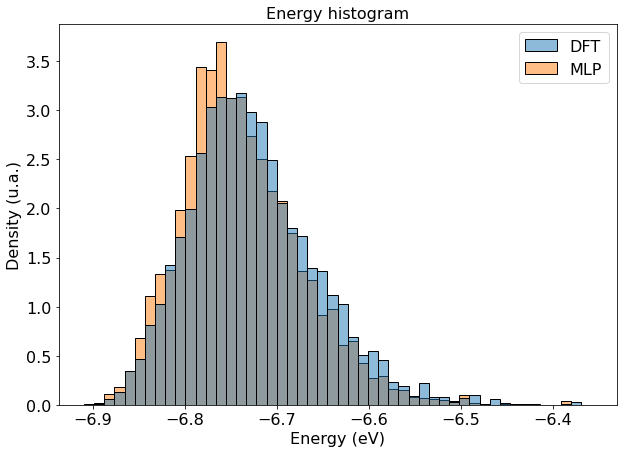

In [31]:
us = {label: torch.cat(adaptive['us']).flatten().detach() for adaptive, label in zip(adaptive_multimodal, ['DFT', 'MLP'])}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=50, alpha=0.5)
axs.set_title(f'Energy histogram')


### 3.g Populations

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Population is1')

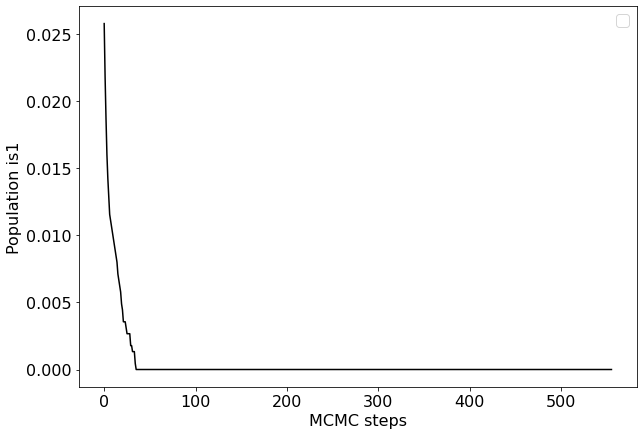

In [159]:
isomers = torch.cat(adaptive_multimodal[0]['isomers'])
isomers_windows = sliding_window_view(isomers.detach().numpy(), 45, axis=0)
population_wind_is1 = np.array([isomer_window.mean() for isomer_window in isomers_windows])

#population_is1 = torch.cat([isomers[i].mean() for i in range(1, isomers.shape[0])])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

#set_plot_sequential_data(torch.tensor(population_is1).flatten().detach(), ax=axs, avg=False, alpha=1)
#set_plot_sequential_data(isomers_windows.mean(axis=1), ax=axs, avg=False, alpha=1)

set_plot_sequential_data(population_wind_is1, ax=axs, avg=False, alpha=1)
#axs.hlines(isomers.mean().detach(), 0, 400, colors='r', linestyles='dashed', label='Mean {:.2f}'.format(isomers.mean().detach()))

axs.legend()
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Population is1')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Population is1')

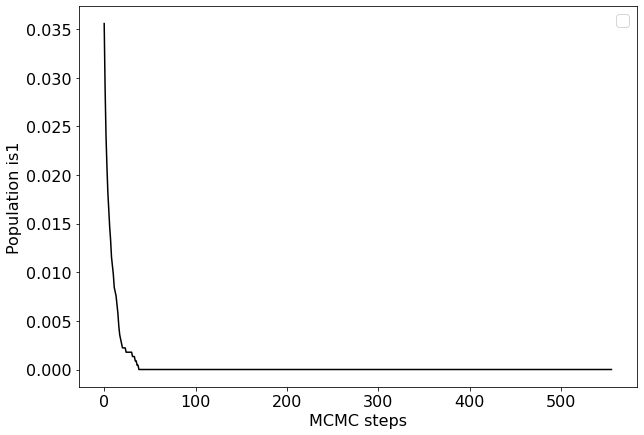

In [160]:
isomers = torch.cat(adaptive_multimodal[1]['isomers'])
isomers_windows = sliding_window_view(isomers.detach().numpy(), 45, axis=0)
population_wind_is1 = np.array([isomer_window.mean() for isomer_window in isomers_windows])

#population_is1 = torch.ca([isomers[i].mean() for i in range(1, isomers.shape[0])])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

#set_plot_sequential_data(torch.tensor(population_is1).flatten().detach(), ax=axs, avg=False, alpha=1)
#set_plot_sequential_data(isomers_windows.mean(axis=1), ax=axs, avg=False, alpha=1)

set_plot_sequential_data(population_wind_is1, ax=axs, avg=False, alpha=1)
#axs.hlines(isomers.mean().detach(), 0, 400, colors='r', linestyles='dashed', label='Mean {:.2f}'.format(isomers.mean().detach()))

axs.legend()
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Population is1')

## 4. Metropolis hastings Mixture

In [5]:
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_28995201/mixture_mcmc_dic_28995201.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29099011/mixture_mcmc_dic_29099011.pkl']
mcmcs = [load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path in mcmc_paths]

### 4.a Acceptance ratio

In [6]:
accs_mcmcs = [mcmc['accs'].mean(dim=1) for mcmc in mcmcs]

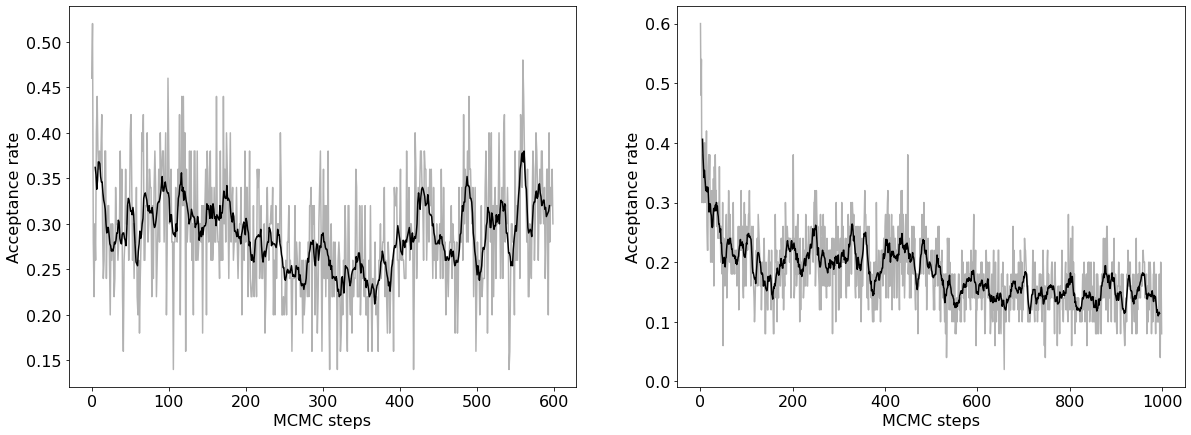

In [7]:

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for ax, accs_mcmc in zip(axs, accs_mcmcs):

    set_plot_sequential_data(accs_mcmc, ax=ax)
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

### 4.b Collective variables

In [9]:
coord_mapping = Coordinates_mapping(etype='dft')

xs = mcmc['xs']
xs_flatten = xs.reshape(-1, 12)

isomers_mask = mcmc['isomers'].reshape(-1, 1)

xs_is0 = []
xs_is1 = []

for isomer, x in zip(isomers_mask, xs_flatten):
    if isomer==0:
        xs_is0.append(x)
    else:
        xs_is1.append(x)

xs_is0 = torch.stack(xs_is0) 
xs_is1 = torch.stack(xs_is1) 

In [10]:
cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)

In [11]:
cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

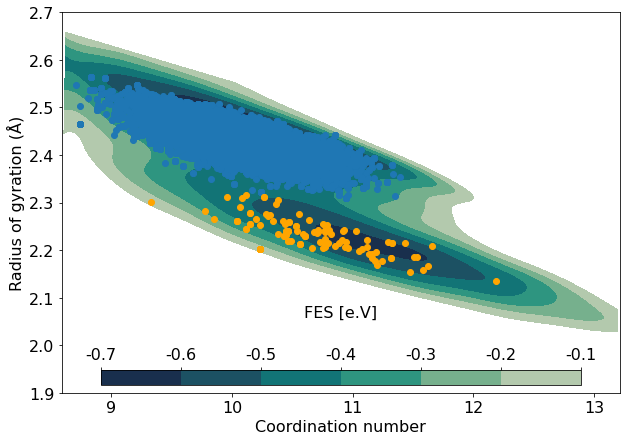

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))

plot_energy_surface(fig=fig, ax=ax)

ax.scatter(cvs_is0[:, 0], cvs_is0[:, 1], )
ax.scatter(cvs_is1[:, 0], cvs_is1[:, 1], c='orange')

### 4.c Jumps between isomers

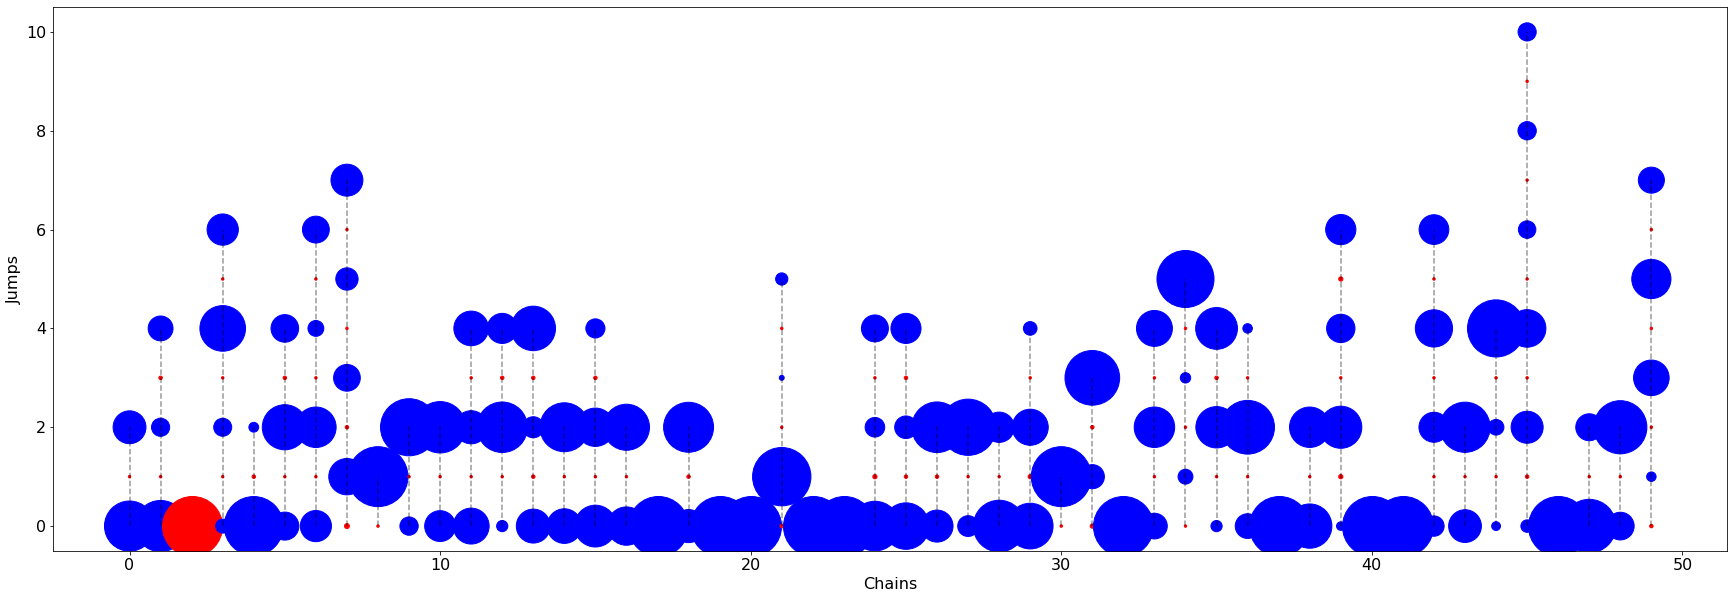

In [8]:
isomers = mcmcs[0]['isomers'].T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(isomers.shape[0]):

    jumps, counts = isomers[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    #print(colors_array)
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*6, color=colors_array)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

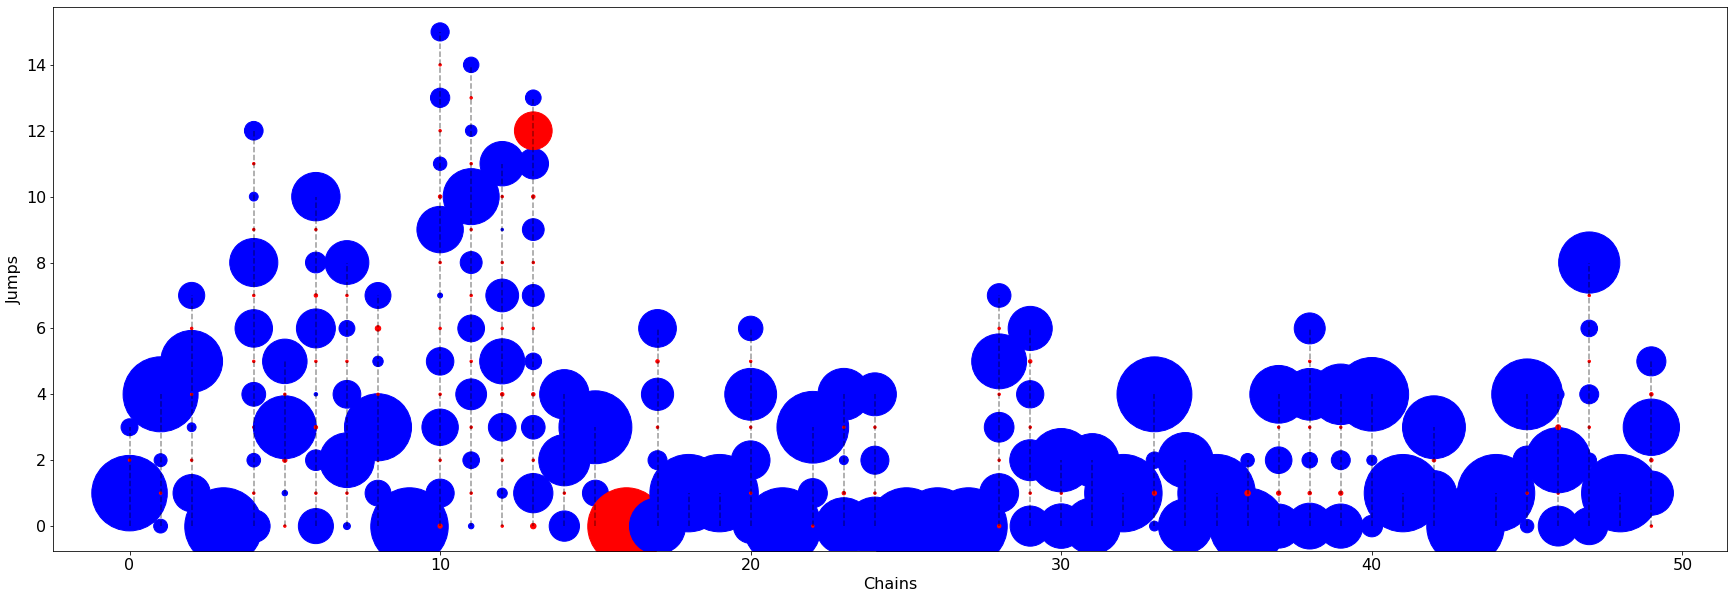

In [9]:
isomers = mcmcs[1]['isomers'].T

fig, ax = plt.subplots(1, 1, figsize=(30, 10))

for i in range(isomers.shape[0]):

    jumps, counts = isomers[i].unique_consecutive(return_counts=True)
    #print(jumps, counts)
    colors_array = []
    for j in range(jumps.shape[0]):
        if jumps[j]==0:
            colors_array.append('blue')
        else:
            colors_array.append('red')
    #print(colors_array)
    ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
    ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*6, color=colors_array)
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

In [12]:
isomers = mcmcs[0]['isomers']

Text(0.5, 1.0, 'DFT')

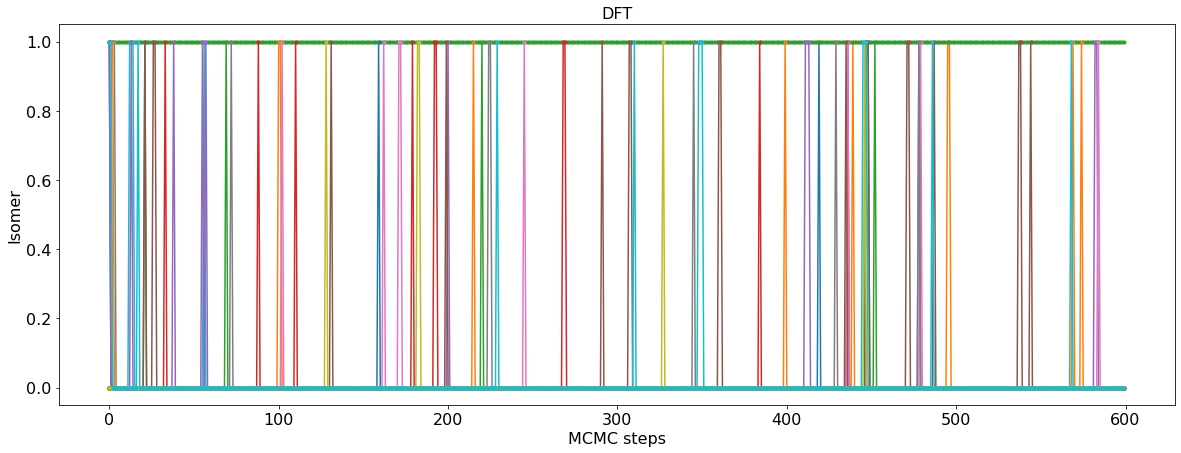

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(isomers.detach().numpy(), '.-')
ax.set_xlabel('MCMC steps')
ax.set_ylabel('Isomer')
ax.set_title('DFT')

Text(0.5, 1.0, 'DFT')

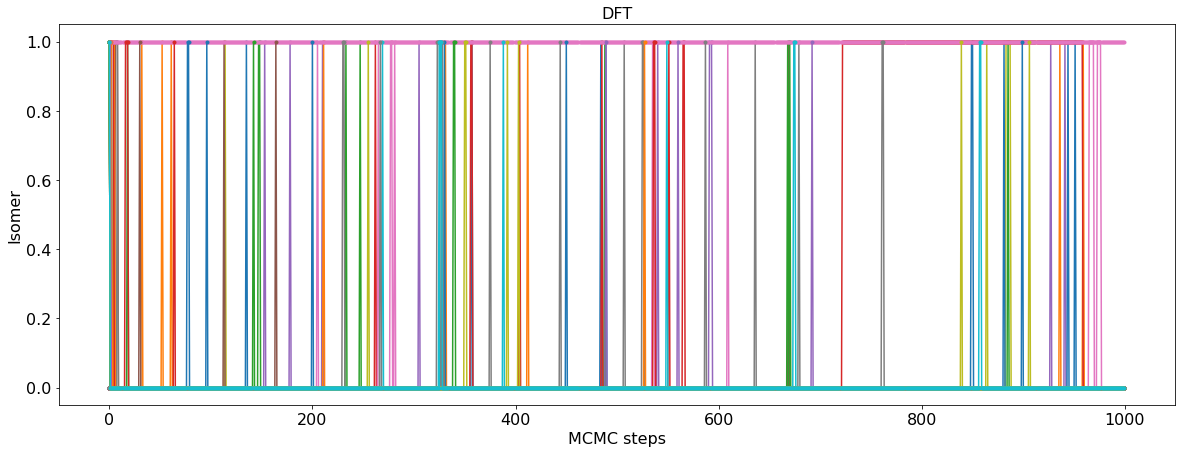

In [48]:
isomers = mcmcs[1]['isomers']

fig, ax = plt.subplots(1, 1, figsize=(20, 7))
ax.plot(isomers.detach().numpy(), '.-')
ax.set_xlabel('MCMC steps')
ax.set_ylabel('Isomer')
ax.set_title('DFT')

### 4.d Rhat test

In [14]:
xs = mcmcs[0]["xs"].detach().numpy().transpose(1, 0, 2)
isomers = mcmcs[0]["isomers"].detach().numpy().transpose(1, 0)

coord_mapping = Coordinates_mapping()

zmat = torch.zeros(xs.shape)

for i in range(xs.shape[1]):
    for j in range(xs.shape[0]):
        zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                    isomer=isomers[j, i])[0]
zmat_dft = zmat.clone().detach().numpy()

In [15]:
xs = mcmcs[1]["xs"].detach().numpy().transpose(1, 0, 2)
isomers = mcmcs[1]["isomers"].detach().numpy().transpose(1, 0)

coord_mapping = Coordinates_mapping()

zmat = torch.zeros(xs.shape)

for i in range(xs.shape[1]):
    for j in range(xs.shape[0]):
        zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                    isomer=isomers[j, i])[0]
zmat_mlp = zmat.clone().detach().numpy()

In [16]:
rhat_s_xs = R_hat(xs)
rhat_s_zmat = [R_hat(zmat) for zmat in [zmat_dft, zmat_mlp]]

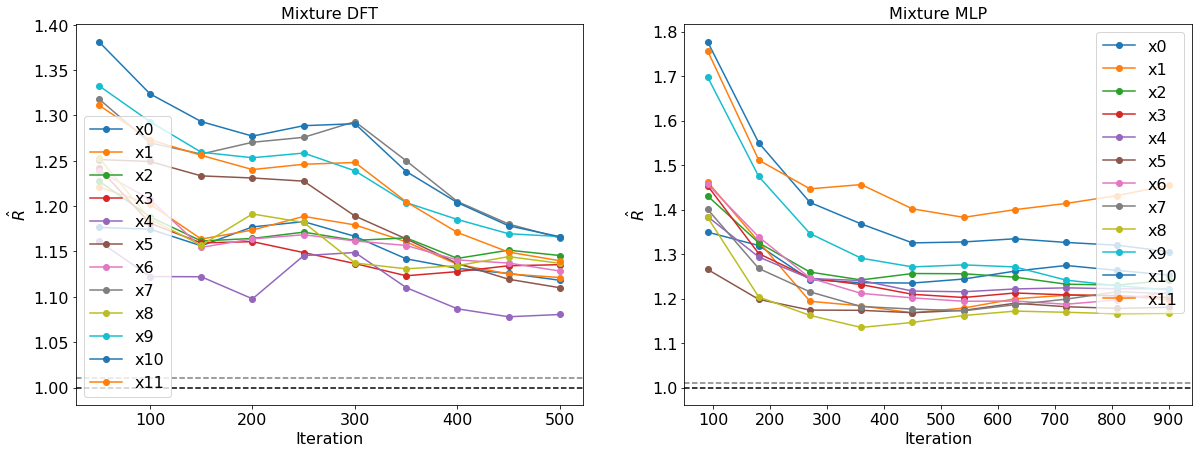

In [17]:
#rhat_s = [rhat_dft[0], rhat_s_zmat]
rhat_s = rhat_s_zmat
coordinates = ["DFT", "MLP"]

fig, axs = plt.subplots(1, len(rhat_s), figsize=(20, 7), sharey=False)

for j in range(len(rhat_s)):
        
    axs[j].plot(rhat_s[j][1], rhat_s[j][0], '-o',  label=rhat_s[j][2])
    axs[j].axhline(1, c='k', ls='--')
    axs[j].axhline(1.01, c='grey', ls='--')
    axs[j].set_xlabel('Iteration')
    axs[j].set_ylabel(r'$\hat{R}$')
    axs[j].legend()
    axs[j].set_title('Mixture {}'.format(coordinates[j]))

### 4.e Energies

Text(0.5, 1.0, 'Energy histogram')

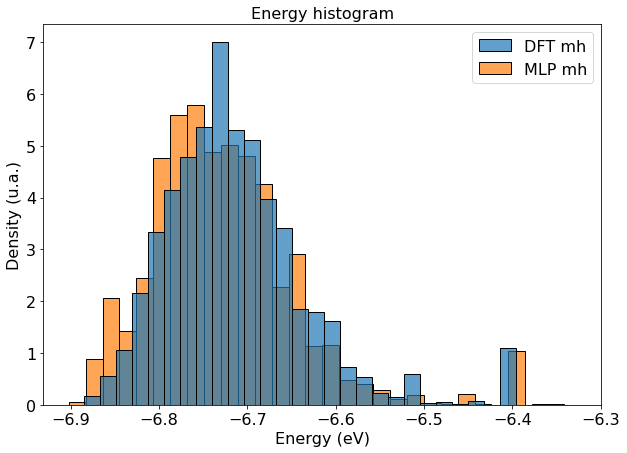

In [30]:
us = {'DFT mh': mcmcs[0]['us'].flatten().detach()}
us['MLP mh'] = mcmcs[1]['us'].flatten().detach()

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.7, hue_order=['DFT mh', 'MLP mh'], common_bins=False, common_norm=False)
axs.set_title(f'Energy histogram')

### 4.e Populations

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 0.05)

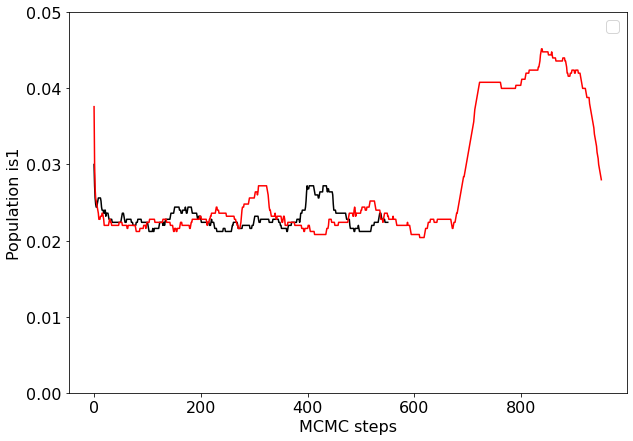

In [21]:
isomers = mcmcs[0]['isomers']
isomers_windows = sliding_window_view(isomers.detach().numpy(), 50, axis=0)
population_wind_is1 = np.array([isomer_window.mean() for isomer_window in isomers_windows])

isomers = mcmcs[1]['isomers']
isomers_windows = sliding_window_view(isomers.detach().numpy(), 50, axis=0)
population_wind_is1_mlp = np.array([isomer_window.mean() for isomer_window in isomers_windows])

#population_is1 = torch.ca([isomers[i].mean() for i in range(1, isomers.shape[0])])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

#set_plot_sequential_data(torch.tensor(population_is1).flatten().detach(), ax=axs, avg=False, alpha=1)
#set_plot_sequential_data(isomers_windows.mean(axis=1), ax=axs, avg=False, alpha=1)

set_plot_sequential_data(population_wind_is1, ax=axs, avg=False, alpha=1)
set_plot_sequential_data(population_wind_is1_mlp, ax=axs, avg=False, alpha=1, color='red')

#axs.hlines(isomers.mean().detach(), 0, 550, colors='r', linestyles='dashed', label='Mean {:.2f}'.format(isomers.mean().detach()))

axs.legend()
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Population is1')
axs.set_ylim(0, 0.05)

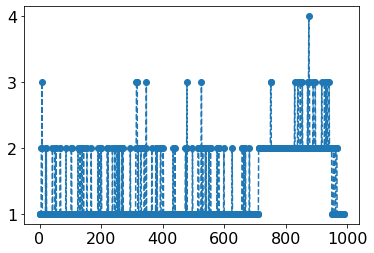

In [28]:
plt.plot(isomers[10:].sum(axis=1).detach(), 'o--')

In [26]:
5/250

0.02

(0.0, 0.05)

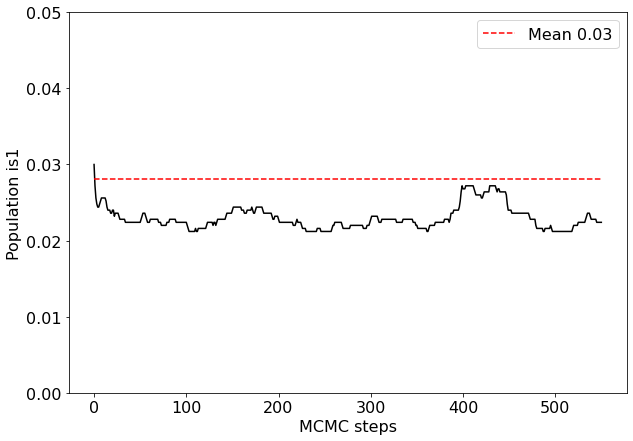

In [65]:
isomers = mcmcs[1]['isomers']
isomers_windows = sliding_window_view(isomers.detach().numpy(), 50, axis=0)
population_wind_is1_mlp = np.array([isomer_window.mean() for isomer_window in isomers_windows])

#population_is1 = torch.ca([isomers[i].mean() for i in range(1, isomers.shape[0])])

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

#set_plot_sequential_data(torch.tensor(population_is1).flatten().detach(), ax=axs, avg=False, alpha=1)
#set_plot_sequential_data(isomers_windows.mean(axis=1), ax=axs, avg=False, alpha=1)

set_plot_sequential_data(population_wind_is1, ax=axs, avg=False, alpha=1)
axs.hlines(isomers.mean().detach(), 0, 550, colors='r', linestyles='dashed', label='Mean {:.2f}'.format(isomers.mean().detach()))

axs.legend()
axs.set_xlabel('MCMC steps')
axs.set_ylabel('Population is1')
axs.set_ylim(0, 0.05)